## STEP 4 (MULTINOMIAL NAIVE BAYES) - MODEL TRAINING
In this step, we're going to train Multinomial Naive Bayes for each personality trait and embedding type using TF-IDF representations.

In [51]:
import os
import pickle
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score

from pipeline.smote_oversampling import SMOTEOversampler

from pipeline.machine_learning_algorithms.multinomial_naive_bayes import MultinomialNaiveBayesClassifier

### First, let's load the datasets and apply oversampling.

In [77]:
with open(
    "../train_datasets/train_datasets/X_train_tfidf.pkl",
    "rb"
) as file:
    X_train_tfidf = pickle.load(file)

with open(
    "../test_datasets/test_datasets/X_test_tfidf.pkl",
    "rb"
) as file:
    X_test_tfidf = pickle.load(file)

with open(
    "../train_datasets/train_datasets/y_train.pkl",
    "rb"
) as file:
    y_train = pd.Series(pickle.load(file))

with open(
    "../test_datasets/test_datasets/y_test.pkl",
    "rb"
) as file:
    y_test = pd.Series(pickle.load(file))

In [76]:
def divide_mbti(y_series):
    y_series = pd.Series(y_series).reset_index(drop=True)

    y_df = pd.DataFrame()

    y_df["I_E"] = (y_series.str[0] == "I").astype(int)
    y_df["N_S"] = (y_series.str[1] == "N").astype(int)
    y_df["T_F"] = (y_series.str[2] == "T").astype(int)
    y_df["J_P"] = (y_series.str[3] == "J").astype(int)

    return y_df

In [54]:
y_test_4cols = divide_mbti(y_test)

## Augmented Data + SMOTE

In [55]:
smote = SMOTEOversampler(random_state=42)

X_train_tfidf_balanced, y_train_balanced = smote.fit_resample(
    X_train_tfidf,
    y_train
)

Original dataset shape: X=(9322, 10000), y=(9322,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)


In [56]:
y_train_4cols_aug_smote = divide_mbti(y_train_balanced)

### Now, we'll train a model using the augmented dataset balanced with SMOTE.

In [57]:
mbti_clf_tfidf_aug_smote = MultinomialNaiveBayesClassifier()

mbti_clf_tfidf_aug_smote.fit(
    X_train_tfidf_balanced,
    y_train_4cols_aug_smote
)

In [58]:
results_tfidf_aug_smote = mbti_clf_tfidf_aug_smote.evaluate(
    X_test_tfidf,
    y_test_4cols
)


Evaluation for dimension: I_E
Accuracy: 0.7579

              precision    recall  f1-score   support

           0       0.41      0.11      0.17       401
           1       0.78      0.95      0.86      1334

    accuracy                           0.76      1735
   macro avg       0.59      0.53      0.51      1735
weighted avg       0.69      0.76      0.70      1735


Evaluation for dimension: N_S
Accuracy: 0.8565

              precision    recall  f1-score   support

           0       0.35      0.05      0.08       240
           1       0.87      0.99      0.92      1495

    accuracy                           0.86      1735
   macro avg       0.61      0.52      0.50      1735
weighted avg       0.79      0.86      0.81      1735


Evaluation for dimension: T_F
Accuracy: 0.7349

              precision    recall  f1-score   support

           0       0.75      0.76      0.76       939
           1       0.71      0.70      0.71       796

    accuracy                       

In [59]:
for dim, model in mbti_clf_tfidf_aug_smote.models.items():
    joblib.dump(
        model,
        f"models/{dim}_tfidf_aug_smote.pkl"
    )

## Original Data

In [60]:
ORIGINAL_TRAIN_SIZE = 6940

X_train_tfidf_original = X_train_tfidf[:ORIGINAL_TRAIN_SIZE]
y_train_original = y_train[:ORIGINAL_TRAIN_SIZE]

In [61]:
y_train_4cols_original = divide_mbti(y_train_original)

### Let's train another model using only the original training dataset for comparison.

In [62]:
mbti_clf_tfidf_original = MultinomialNaiveBayesClassifier()

mbti_clf_tfidf_original.fit(
    X_train_tfidf_original,
    y_train_4cols_original
)

In [63]:
results_tfidf_original = mbti_clf_tfidf_original.evaluate(
    X_test_tfidf,
    y_test_4cols
)      


Evaluation for dimension: I_E
Accuracy: 0.7683

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       401
           1       0.77      1.00      0.87      1334

    accuracy                           0.77      1735
   macro avg       0.38      0.50      0.43      1735
weighted avg       0.59      0.77      0.67      1735


Evaluation for dimension: N_S
Accuracy: 0.8617

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       240
           1       0.86      1.00      0.93      1495

    accuracy                           0.86      1735
   macro avg       0.43      0.50      0.46      1735
weighted avg       0.74      0.86      0.80      1735


Evaluation for dimension: T_F
Accuracy: 0.7614

              precision    recall  f1-score   support

           0       0.74      0.86      0.80       939
           1       0.80      0.64      0.71       796

    accuracy                       

In [64]:
for dim, model in mbti_clf_tfidf_original.models.items():
    joblib.dump(
        model,
        f"models/{dim}_tfidf_original.pkl"
    )

## Original Data + SMOTE

In [65]:
X_train_original_balanced, y_train_original_balanced = (
    smote.fit_resample(
        X_train_tfidf_original,
        y_train_original
    )
)

Original dataset shape: X=(6940, 10000), y=(6940,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)


In [66]:
y_train_4cols_original_smote = divide_mbti(
    y_train_original_balanced
)

### Finally, let's evaluate the impact of applying only SMOTE to the original dataset.

In [67]:
mbti_clf_tfidf_original_smote = (
    MultinomialNaiveBayesClassifier()
)

mbti_clf_tfidf_original_smote.fit(
    X_train_original_balanced,
    y_train_4cols_original_smote
)

In [68]:
results_tfidf_original_smote = (
    mbti_clf_tfidf_original_smote.evaluate(
        X_test_tfidf,
        y_test_4cols
    )
)


Evaluation for dimension: I_E
Accuracy: 0.7308

              precision    recall  f1-score   support

           0       0.39      0.31      0.35       401
           1       0.81      0.86      0.83      1334

    accuracy                           0.73      1735
   macro avg       0.60      0.58      0.59      1735
weighted avg       0.71      0.73      0.72      1735


Evaluation for dimension: N_S
Accuracy: 0.8398

              precision    recall  f1-score   support

           0       0.40      0.30      0.34       240
           1       0.89      0.93      0.91      1495

    accuracy                           0.84      1735
   macro avg       0.64      0.61      0.63      1735
weighted avg       0.82      0.84      0.83      1735


Evaluation for dimension: T_F
Accuracy: 0.7182

              precision    recall  f1-score   support

           0       0.78      0.67      0.72       939
           1       0.66      0.78      0.72       796

    accuracy                       

In [69]:
for dim, model in mbti_clf_tfidf_original_smote.models.items():
    joblib.dump(
        model,
        f"models/{dim}_tfidf_original_smote.pkl"
    )

## Results

### Finally, let's compare the results obtained in all experimental settings.

In [70]:
pred_original = mbti_clf_tfidf_original.predict(
    X_test_tfidf
)

pred_original_smote = (
    mbti_clf_tfidf_original_smote.predict(
        X_test_tfidf
    )
)

pred_aug_smote = mbti_clf_tfidf_aug_smote.predict(
    X_test_tfidf
)

In [71]:
dimensions = ["I_E", "N_S", "T_F", "J_P"]

axis_names = [
    "I/E\n(Introvert/Extravert)",
    "N/S\n(Intuition/Sensing)",
    "T/F\n(Thinking/Feeling)",
    "J/P\n(Judging/Perceiving)"
]

In [72]:
data = []

for index, dim in enumerate(dimensions):
    data.append({
        "Axis": axis_names[index],
        "F1 (%)": f1_score(
            y_test_4cols[dim],
            pred_original[dim],
            average="weighted",
            zero_division=0
        ) * 100,
        "Method": "1. Original"
    })

    data.append({
        "Axis": axis_names[index],
        "F1 (%)": f1_score(
            y_test_4cols[dim],
            pred_original_smote[dim],
            average="weighted",
            zero_division=0
        ) * 100,
        "Method": "2. Original + SMOTE"
    })

    data.append({
        "Axis": axis_names[index],
        "F1 (%)": f1_score(
            y_test_4cols[dim],
            pred_aug_smote[dim],
            average="weighted",
            zero_division=0
        ) * 100,
        "Method": "3. SLM Aug + SMOTE"
    })

In [73]:
df_results = pd.DataFrame(data)

display(df_results)

,Axis,F1 (%),Method
0,I/E\n(Introvert/Extravert),66.813026,1. Original
1,I/E\n(Introvert/Extravert),71.870997,2. Original + SMOTE
2,I/E\n(Introvert/Extravert),69.920796,3. SLM Aug + SMOTE
3,N/S\n(Intuition/Sensing),79.764635,1. Original
4,N/S\n(Intuition/Sensing),83.028285,2. Original + SMOTE
5,N/S\n(Intuition/Sensing),80.583132,3. SLM Aug + SMOTE
6,T/F\n(Thinking/Feeling),75.749644,1. Original
7,T/F\n(Thinking/Feeling),71.823258,2. Original + SMOTE
8,T/F\n(Thinking/Feeling),73.467513,3. SLM Aug + SMOTE
9,J/P\n(Judging/Perceiving),53.411323,1. Original


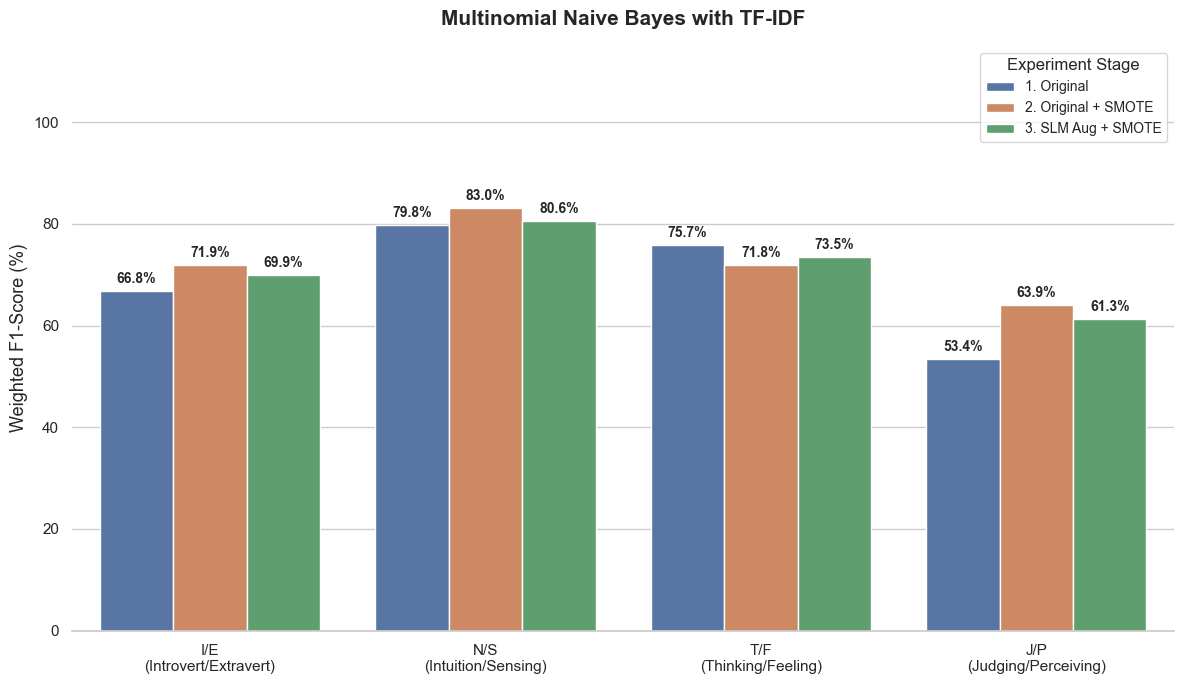

In [74]:
plt.figure(figsize=(12, 7))

sns.set_theme(style="whitegrid")

axis = sns.barplot(
    data=df_results,
    x="Axis",
    y="F1 (%)",
    hue="Method"
)

axis.set_title(
    "Multinomial Naive Bayes with TF-IDF",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axis.set_ylim(0, 115)

axis.set_ylabel(
    "Weighted F1-Score (%)",
    fontsize=13
)

axis.set_xlabel("")

for bar in axis.patches:
    height = bar.get_height()

    if height > 0:
        axis.annotate(
            f"{height:.1f}%",
            (
                bar.get_x() + bar.get_width() / 2,
                height
            ),
            ha="center",
            va="baseline",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 6),
            textcoords="offset points"
        )

axis.legend(
    title="Experiment Stage",
    fontsize=10,
    loc="upper right"
)

sns.despine(
    left=True,
    bottom=False
)

plt.tight_layout()
plt.show()